## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [1]:
import ray
from ray import train, tune

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]
#

In [4]:
def rhoOmega_offset(rho_true,rho_pred,range=3):
    return np.sum(np.abs(rho_true[:range]-np.squeeze(rho_pred.numpy())[:range]))/range

In [5]:
base_ep_noise=0#3e-2
num_samples = 30
ep_noise=3e-2
seed=0

def train_NN_multifit(config):
    import physicsHelper
    import models
    import lossCalculator
    import correlator
    import tensorflow as tf
    
    spec2BW = physicsHelper.BWfun(A,Ga,M,omega)
    spec2BWOverOmega = physicsHelper.BWfunOverOmega(A,Ga,M,omega)
    rho_true = spec2BWOverOmega

    x = np.linspace(0,19.2+0,25)
    del_xi = x[1]-x[0]

    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

    ##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
    Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

    noisy_dxi_tensor = []
    base_noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,base_ep_noise,seed=seed)
    if num_samples == 1:
        noisy_dxi_tensor.append(base_noisy_Dxi)
    else:
        for ii in range(num_samples):
            noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(base_noisy_Dxi,x,ep_noise)
            noisy_dxi_tensor.append(noisy_Dxi_sample)

    target_output = tf.constant(base_noisy_Dxi, dtype=tf.float32)
    target_output=noisy_dxi_tensor
    gauss_width = np.ones(len(x)) #for mean square error
    gauss_width=custom_std
    kern=klW_ker_Pos
    constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
    
    model = models.SpectralNN(num_output_nodes=500, width=config["width"], depth=config["depth"])
    lossCalc=lossCalculator.LossCalculatorHyperTuning(model=model,
                                            y_true=target_output,
                                            kernel=kern,
                                            delomega=del_omega,
                                            x=constant_input,
                                            std=gauss_width,
                                            lambda_s_func_warmup=lambda x:config["lambda_s_warmup"],
                                            lambda_s_func=lambda x:config["lambda_s"],
                                            lambda_l2_func_warmup=lambda x:config["lambda_l2_warmup"],
                                            lambda_l2_func=lambda x:config["lambda_l2"]
                                            )
    # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    trainer=models.networkTrainer(model,optimizer,lossCalc)
    total_loss_history_warmup,loss_history_warmup=trainer.train(config["warmup_epochs"],warmup=True,verbose=True)

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history,loss_history=trainer.train(config["train_epochs"],warmup=False,verbose=True)
    rho_pred=model(constant_input)

    return rhoOmega_offset(rho_true,rho_pred,range=2)

In [6]:
# config = {
#     "lambda_s_warmup": 1.0e-2,
#     "lambda_l2_warmup": 1.0e-4,
#     "lambda_s": 1.0e-5,
#     "lambda_l2": 1.0e-8,
#     "warmup_epochs": 20
# }

# print(train_NN_multifit(config))

In [7]:
search_space = { 
    "lambda_s_warmup": 1.0e-2,#tune.loguniform(1.0e-2, 1.0e-1),
    "lambda_l2_warmup": 1.0e-4,#tune.loguniform(1.0e-4, 1.0e-3),
    "lambda_s": tune.loguniform(1.0e-7, 1.0e-3),
    "lambda_l2": tune.loguniform(1.0e-10, 1.0e-6),
    "warmup_epochs": 1000,
    "width": 64,
    "depth": 3,
    "train_epochs": 30000
}

In [8]:
ray.init(num_cpus=16)
trainable_with_resources = tune.with_resources(train_NN_multifit, {"cpu": 1})
tuner = tune.Tuner(trainable_with_resources, param_space=search_space,tune_config=tune.TuneConfig(num_samples=128)) 

2024-12-06 11:56:35,679	INFO worker.py:1821 -- Started a local Ray instance.


In [9]:
results = tuner.fit()

(train_NN_multifit pid=28363) 2024-12-06 11:56:38.966671: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(train_NN_multifit pid=28363) 2024-12-06 11:56:38.967584: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
(train_NN_multifit pid=28375) 2024-12-06 11:56:38.962620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(train_NN_multifit pid=28367) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(train_NN_multifit pid=28367) E0000 00:00:1733482598.954167   29258 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to registe

(train_NN_multifit pid=28367) Training for 1000 epochs
(train_NN_multifit pid=28367) Epoch 0, Loss: 753.9130859375
(train_NN_multifit pid=28370) Training for 1000 epochs [repeated 15x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(train_NN_multifit pid=28363) Epoch 500, Loss: 0.004015588667243719 [repeated 61x across cluster]
(train_NN_multifit pid=28362) Epoch 700, Loss: 0.002531358739361167 [repeated 52x across cluster]
(train_NN_multifit pid=28366) Training took 11.364163160324097 seconds
(train_NN_multifit pid=28366) Training for 30000 epochs
(train_NN_multifit pid=28365) Epoch 600, Loss: 0.004198737442493439 [repeated 34x across cluster]
(train_NN_multifit pid=28375) Training took 16.382569074630737 seconds [repeated 8x across cluster]
(train_NN_multifit pid=28375) Training for 30000 epochs [repeated 

(train_NN_multifit pid=31492) 2024-12-06 12:05:11.965124: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`. [repeated 16x across cluster]
(train_NN_multifit pid=31492) 2024-12-06 12:05:11.970434: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used. [repeated 33x across cluster]
(train_NN_multifit pid=31492) 2024-12-06 12:05:11.985494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 16x across cluster]
(train_NN_multifit pid=31492) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 16x across cluster]
(train_NN_multifit pi

(train_NN_multifit pid=31492) Training for 1000 epochs
(train_NN_multifit pid=28367) Epoch 27000, Loss: 3.686194759211503e-05 [repeated 3x across cluster]
(train_NN_multifit pid=28365) Epoch 24000, Loss: 3.935767017537728e-05 [repeated 6x across cluster]
(train_NN_multifit pid=28366) Training took 510.9883029460907 seconds


(train_NN_multifit pid=31681) 2024-12-06 12:05:26.745640: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(train_NN_multifit pid=31681) 2024-12-06 12:05:26.749271: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used. [repeated 2x across cluster]
(train_NN_multifit pid=31681) 2024-12-06 12:05:26.758383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(train_NN_multifit pid=31681) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(train_NN_multifit pid=31681) E0000 00:00:1733483126.774484   31743 cuda_dnn.cc:8310] Unable to register cuDNN f

...

(train_NN_multifit pid=57484) 2024-12-06 13:07:35.184699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(train_NN_multifit pid=57484) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(train_NN_multifit pid=57484) E0000 00:00:1733486855.200472   57612 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(train_NN_multifit pid=57484) E0000 00:00:1733486855.204992   57612 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(train_NN_multifit pid=57484) 2024-12-06 13:07:35.171980: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different 

(train_NN_multifit pid=57491) Training for 1000 epochs
(train_NN_multifit pid=53800) Training took 592.1049404144287 seconds
(train_NN_multifit pid=57491) Epoch 100, Loss: 0.17963072657585144 [repeated 6x across cluster]
(train_NN_multifit pid=57484) Training for 1000 epochs
(train_NN_multifit pid=57491) Epoch 400, Loss: 0.010491810739040375 [repeated 5x across cluster]
(train_NN_multifit pid=57484) Epoch 400, Loss: 0.009572646580636501 [repeated 5x across cluster]
(train_NN_multifit pid=57491) Training took 14.887563228607178 seconds
(train_NN_multifit pid=57491) Training for 30000 epochs
(train_NN_multifit pid=57484) Epoch 600, Loss: 0.0031511280685663223 [repeated 5x across cluster]
(train_NN_multifit pid=57484) Epoch 800, Loss: 0.002075022319331765 [repeated 3x across cluster]
(train_NN_multifit pid=54173) Training took 600.80069231987 seconds
(train_NN_multifit pid=57484) Training for 30000 epochs
(train_NN_multifit pid=57484) Epoch 0, Loss: 0.0019216617802157998 [repeated 3x acro

(train_NN_multifit pid=57807) 2024-12-06 13:08:08.324789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 2x across cluster]
(train_NN_multifit pid=57807) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(train_NN_multifit pid=57807) E0000 00:00:1733486888.341002   57871 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(train_NN_multifit pid=57807) E0000 00:00:1733486888.345462   57871 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(train_NN_multifit pid=57807) 2024-12-06 13:08:08.315663: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Cou

(train_NN_multifit pid=57484) Training took 29.008877515792847 seconds
(train_NN_multifit pid=57807) Training for 1000 epochs
(train_NN_multifit pid=57807) Epoch 200, Loss: 0.059717047959566116 [repeated 6x across cluster]
(train_NN_multifit pid=57807) Epoch 600, Loss: 0.0029815752059221268 [repeated 5x across cluster]
(train_NN_multifit pid=57807) Training took 13.851027250289917 seconds
(train_NN_multifit pid=57807) Training for 30000 epochs
(train_NN_multifit pid=57807) Epoch 0, Loss: 0.0018425839953124523 [repeated 7x across cluster]
(train_NN_multifit pid=55849) Epoch 12000, Loss: 5.6172098993556574e-05
(train_NN_multifit pid=56427) Epoch 12000, Loss: 3.682786336867139e-05
(train_NN_multifit pid=57491) Epoch 3000, Loss: 4.354863631306216e-05 [repeated 3x across cluster]
(train_NN_multifit pid=55665) Epoch 18000, Loss: 3.7727477320004255e-05 [repeated 2x across cluster]
(train_NN_multifit pid=56675) Epoch 9000, Loss: 4.4368585804477334e-05 [repeated 6x across cluster]
(train_NN_mul

2024-12-06 13:15:30,582	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/lpannullo/ray_results/train_NN_multifit_2024-12-06_11-56-36' in 0.0424s.
2024-12-06 13:15:30,607	INFO tune.py:1041 -- Total run time: 4733.12 seconds (4733.03 seconds for the tuning loop).


In [15]:
print(results.get_best_result(metric="_metric", mode="min").config)

{'lambda_s_warmup': 0.01, 'lambda_l2_warmup': 0.0001, 'lambda_s': 6.9877915950256485e-06, 'lambda_l2': 2.3667835227018086e-07, 'warmup_epochs': 1000, 'width': 64, 'depth': 3, 'train_epochs': 30000}


Text(0, 0.5, 'lambda_l2')

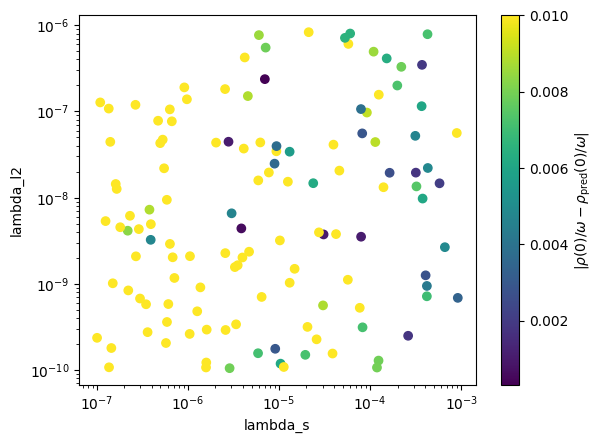

In [14]:
data=[]

for result in results:
   data.append([result.config["lambda_s"],result.config["lambda_l2"],result.metrics["_metric"]])

data=np.array(data)
#plot data
fig, ax = plt.subplots()
scat=ax.scatter(data[:,0],data[:,1],c=np.abs(data[:,2]),cmap='viridis',vmax=0.01)

#colorbar
cbar = plt.colorbar(scat,label=r'$|\rho(0)/\omega - \rho_\mathrm{pred}(0)/\omega|$')


plt.xscale('log')
plt.yscale('log')

plt.xlabel('lambda_s')
plt.ylabel('lambda_l2')

